# Data Mining

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from src.categories import tp_level_categories
from src.descriptions import df_measurements, df_descriptions
from src.eda import understand_features
from src.enums import files, keys, prefixes
from src.serialize import dump_to_file

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

IMAGE_PATH = 'images'
os.makedirs(IMAGE_PATH, exist_ok=True)

df = pd.read_csv(files['data/04-03-dataset.csv'])

## Understand features

In [3]:
understand_features(df, df_measurements, df_descriptions)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RSV_TP_LEVEL              138 non-null    object 
 1   nitrogen_dioxide (μg/m³)  138 non-null    float64
 2   carbon_monoxide (μg/m³)   138 non-null    float64
 3   uv_index ()               138 non-null    float64
 4   ozone (μg/m³)             138 non-null    float64
 5   MMWR_WEEK                 138 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 6.6+ KB


,Measurement Type,Description
nitrogen_dioxide (μg/m³),ratio,Vehicle emissions can cause airway inflammation.
carbon_monoxide (μg/m³),ratio,"Odorless gas from combustion, reduces oxygen d..."
uv_index (),ratio,Measurement of the intensity of ultraviolet ra...
ozone (μg/m³),ratio,Created by chemical reactions between oxides o...
RSV_TP_LEVEL,ordinal,Positivity level based on 5 seasons of RSV data.
MMWR_WEEK,interval,Standardized CDC week number (1 to 52 or 53).


## Data Preparation

### Discretize target variable

In [4]:
df[keys['RSV_TP_LEVEL']] = pd.Categorical(
    df[keys['RSV_TP_LEVEL']],
    categories=tp_level_categories,
    ordered=True
)
df[keys['RSV_TP_LEVEL']] = df[keys['RSV_TP_LEVEL']].cat.codes

### Split dataset

In [5]:
target = df[keys['RSV_TP_LEVEL']]
features = df.drop(columns=['RSV_TP_LEVEL'])

## Random Forest Classifier (RF)

In [6]:
def get_rf_classifier():
    return RandomForestClassifier(
                n_estimators=100,
                min_samples_leaf=3,
                min_samples_split=2,
                random_state=RANDOM_STATE
            )
def get_lg():
    return LogisticRegression(
                max_iter=1000, 
                class_weight='balanced', 
                random_state=RANDOM_STATE
            )

### RandomForest Classifier with multiple runs

In [7]:
# random_forest_step_by_step_v2.ipynb
accs = []
lg_accs = []
n_run = 4
for i in range(n_run):
    xTrain, xTest, yTrain, yTest = train_test_split(
        features, target, test_size=0.3, stratify=target, random_state=i
    )
    random_forest = get_rf_classifier()
    random_forest.fit(xTrain, yTrain)
    acc = accuracy_score(yTest, random_forest.predict(xTest))
    accs.append(acc)

    s_scaler = StandardScaler()
    x_train_scaled = s_scaler.fit_transform(xTrain)
    x_test_scaled = s_scaler.transform(xTest)
    lg = get_lg()
    lg.fit(x_train_scaled, yTrain)
    lg_acc = accuracy_score(yTest, lg.predict(x_test_scaled))
    lg_accs.append(lg_acc)
  
accs = np.array(accs)
print(f'RF Accuracy Mean: {accs.mean()}')
lg_accs = np.array(lg_accs)
print(f'LG Accuracy Mean: {lg_accs.mean()}')


RF Accuracy Mean: 0.6488095238095238
LG Accuracy Mean: 0.625


### Train and Test Split

In [8]:
xTrain, xTest, yTrain, yTest = train_test_split(features, target, test_size=0.3, stratify=target, random_state=i)

### Train and Test using RandomForest Classifier

----------------------------------
Random Forest
Accuracy: 0.6904761904761905
F1: 0.6572263993316624
Precision: 0.641465677179963
Recall: 0.6904761904761905
----------------------------------


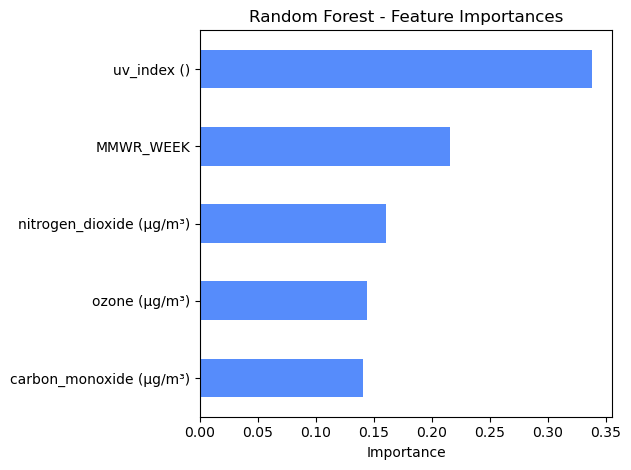

In [9]:
random_forest = get_rf_classifier()
random_forest.fit(xTrain, yTrain)

y_pred = random_forest.predict(xTest)
acc = accuracy_score(yTest, y_pred)
f1 = f1_score(yTest, y_pred, average='weighted', zero_division=0)
precision = precision_score(yTest, y_pred, average='weighted', zero_division=0)
recall = recall_score(yTest, y_pred, average='weighted', zero_division=0)
print('----------------------------------')
print('Random Forest')
print(f'Accuracy: {acc}')
print(f'F1: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print('----------------------------------')
importances = pd.Series(random_forest.feature_importances_, index=features.columns).sort_values()
fig = plt.figure()
importances.plot(kind='barh')
plt.title("Random Forest - Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_PATH, "04-03-data-mining-rf-feature-important.png"), dpi=300)
plt.show()

### RF Confusion Matrix

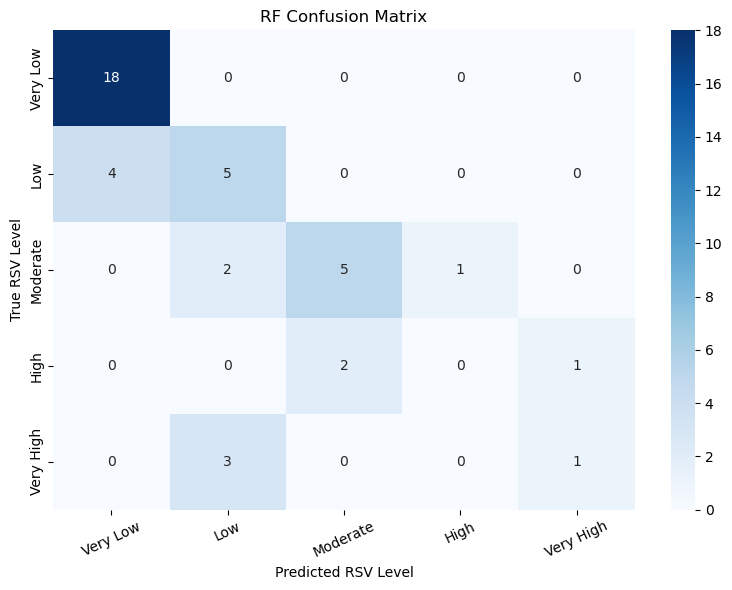

In [10]:
rf_cfm = confusion_matrix(yTest, random_forest.predict(xTest))
plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cfm,
    xticklabels=tp_level_categories,
    yticklabels=tp_level_categories,
    annot=True,
    cmap='Blues',
)
plt.title("RF Confusion Matrix")
plt.xlabel("Predicted RSV Level")
plt.ylabel("True RSV Level")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_PATH, "04-03-data-mining-rf-confusion-matrix.png"), dpi=300)
plt.show()


## Train and Test using Logistic Regression

----------------------------------
Logistic Regression
Accuracy: 0.6190476190476191
F1: 0.6007798383738232
Precision: 0.617517006802721
Recall: 0.6190476190476191
----------------------------------


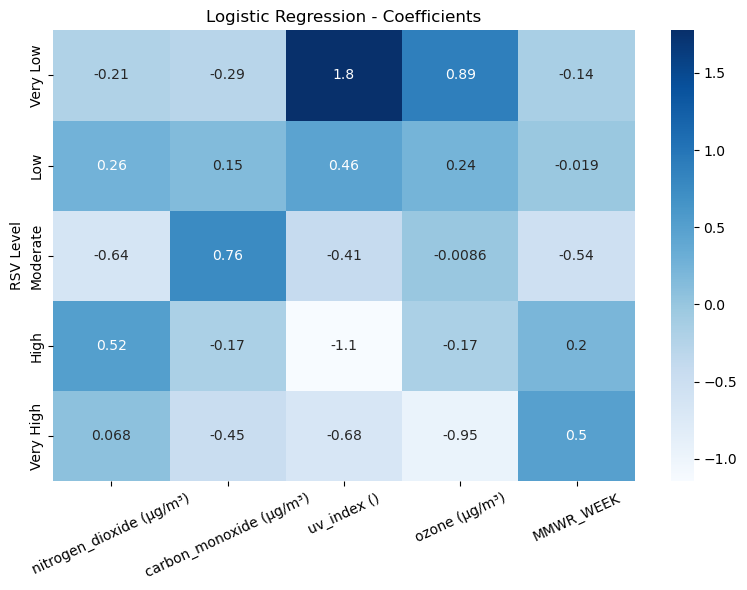

In [11]:
s_scaler = StandardScaler()
x_train_scaled = s_scaler.fit_transform(xTrain)
x_test_scaled = s_scaler.transform(xTest)
lg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lg.fit(x_train_scaled, yTrain)
y_pred = lg.predict(x_test_scaled)
acc = accuracy_score(yTest, y_pred)
f1 = f1_score(yTest, y_pred, average='weighted', zero_division=0)
precision = precision_score(yTest, y_pred, average='weighted', zero_division=0)
recall = recall_score(yTest, y_pred, average='weighted', zero_division=0)
print('----------------------------------')
print('Logistic Regression')
print(f'Accuracy: {acc}')
print(f'F1: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print('----------------------------------')


coeffs = lg.coef_

plt.figure(figsize=(8, 6))
sns.heatmap(
    coeffs,
    xticklabels=features.columns,
    yticklabels=tp_level_categories,
    annot=True,
    cmap='Blues',
)
plt.title("Logistic Regression - Coefficients")
plt.ylabel("RSV Level")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_PATH, "04-03-data-mining-logistic-regression-coefficients.png"), dpi=300)
plt.show()

References:
1. random_forest_step_by_step_v2.ipynb

2. RandomForestClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
